In [1]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = "/content"
!chmod 600 /content/kaggle.json

In [2]:
!pip install kaggle --quiet
!kaggle datasets download -d mlg-ulb/creditcardfraud

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 235MB/s]



In [3]:
import zipfile

with zipfile.ZipFile('/content/creditcardfraud.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

In [4]:
import pandas as pd

df = pd.read_csv('/content/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [6]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [7]:
df.duplicated().sum()

np.int64(1081)

In [8]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [9]:
df.groupby('Class')['Amount'].mean()

,Amount
Class,
0,88.413575
1,123.871860


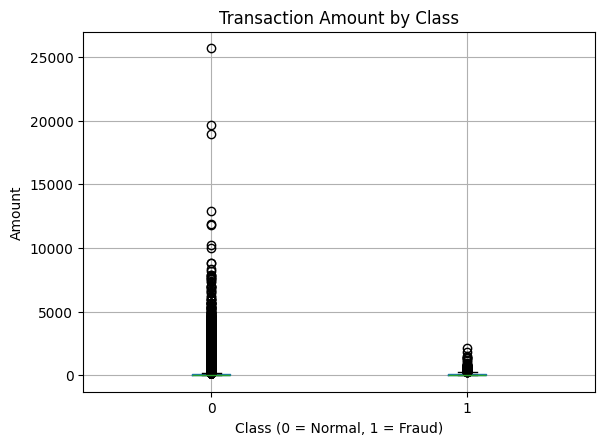

In [10]:
import matplotlib.pyplot as plt

df.boxplot(column='Amount', by='Class')
plt.title('Transaction Amount by Class')
plt.suptitle('')
plt.xlabel('Class (0 = Normal, 1 = Fraud)')
plt.ylabel('Amount')
plt.show()

In [11]:
!pip install imbalanced-learn --quiet

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [13]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [14]:
y_train_resampled.value_counts()

,count
Class,
0,226602
1,226602


In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_resampled, y_train_resampled)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

In [17]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train_resampled)

LogisticRegression(max_iter=1000)

In [18]:
y_pred = model.predict(X_test_scaled)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56651
           1       0.14      0.85      0.24        95

    accuracy                           0.99     56746
   macro avg       0.57      0.92      0.62     56746
weighted avg       1.00      0.99      0.99     56746

[[56163   488]
 [   14    81]]


In [19]:
from sklearn.metrics import roc_auc_score

y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9629093740157882


In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train_resampled)

RandomForestClassifier(random_state=42)

In [21]:
y_pred_rf = rf_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.89      0.77      0.82        95

    accuracy                           1.00     56746
   macro avg       0.94      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746

[[56642     9]
 [   22    73]]


In [22]:
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print("Random Forest ROC-AUC Score:", roc_auc_rf)

Random Forest ROC-AUC Score: 0.9608938941942773


In [23]:
import pandas as pd

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(feature_importance)

V14       0.218747
V10       0.130709
V12       0.108896
V4        0.101697
V17       0.093440
V3        0.073695
V11       0.053490
V16       0.040685
V2        0.038452
V9        0.026547
V21       0.013342
V7        0.011992
V1        0.009738
V6        0.009426
V18       0.007999
Time      0.006774
V27       0.005818
V8        0.005312
V13       0.004501
Amount    0.003881
V19       0.003852
V20       0.003825
V22       0.003802
V5        0.003713
V26       0.003708
V15       0.003615
V28       0.003474
V25       0.003256
V24       0.002950
V23       0.002665
dtype: float64


In [24]:
lr_importance = pd.Series(model.coef_[0], index=X.columns).sort_values(ascending=False)
print(lr_importance)

V1        6.245909
V5        4.075419
V3        3.270512
V4        2.676030
V11       2.410457
V2        2.372647
Amount    2.349523
V22       0.931371
V19       0.850479
V23       0.716894
V28       0.486915
V21       0.288940
V24       0.129220
V25      -0.056009
V26      -0.079554
V27      -0.195938
Time     -0.310961
V15      -0.352490
V13      -0.493559
V6       -0.946796
V20      -1.151920
V18      -1.612317
V9       -1.645642
V8       -2.368620
V16      -3.183500
V7       -5.069000
V10      -5.874073
V12      -7.864538
V17      -9.609022
V14      -9.750841
dtype: float64


In [25]:
fraud_probabilities = rf_model.predict_proba(X_test_scaled)[:, 1]

risk_level = pd.cut(fraud_probabilities, bins=[0, 0.3, 0.7, 1.0], labels=['Low', 'Medium', 'High'])

risk_level.value_counts()

,count
Low,6298
Medium,18
High,71


In [26]:
risk_level.isnull().sum()

np.int64(50359)

In [27]:
risk_level = pd.cut(fraud_probabilities, bins=[-0.01, 0.3, 0.7, 1.0], labels=['Low', 'Medium', 'High'])
risk_level.value_counts()

,count
Low,56657
Medium,18
High,71


In [28]:
pd.crosstab(y_test, risk_level)

col_0,Low,Medium,High
Class,,,
0,56637,11,3
1,20,7,68
